<a href="https://colab.research.google.com/github/rangaraju1/Generative-AI-and-LLM-Applications/blob/main/Processing_Medical_Information_using_OpenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

1. Access Open AI APIs.
2. Understand the API structure of prompts presented to LLMs.


# Setup

Azure provides seamless integration with the OpenAI API to provide access to the GPT-series of models.

In [1]:
!pip install -q openai==1.66.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 10.0 MB/s eta 0:00:00


## Authentication

To enable API access at scale, we will need to authorize our compute infrastructure (in this case the Colab notebook) to programmatically access Open AI APIs. This authentication is managed by storing the API secret keys within the secrets tab of Colab (see the steps below).

Paste your Open AI API key in the secrets tab in the left panel.

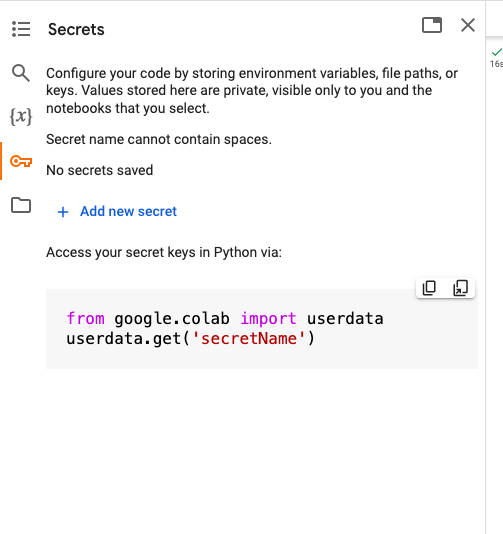

Ensure that you enable notebook access

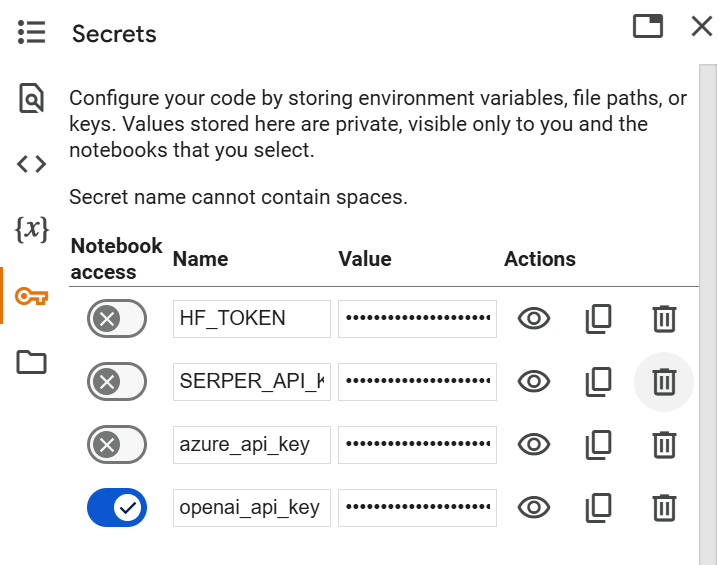

Note that this is a one time exercise, and the API key will be available across all your Colab notebooks linked to the Google account.

In [2]:
from openai import OpenAI

from google.colab import userdata

Now we can read the API key from Colab secrets. This way we do not expose our API keys in a notebook. Note that a secret once created is shared across all Colab notebooks.

In [3]:
openai_api_key = userdata.get('openai_api_key')

With authentication in place, we can now instantiate a client that will access models hosted on Open AI and exposed to us as APIs.

In [4]:
client = OpenAI(
    api_key=openai_api_key,
    base_url="https://aibe.mygreatlearning.com/openai/v1"
)

In [5]:
model_name = 'gpt-4o-mini'

# Sending API Requests

There are two main APIs that Open AI offers to send prompts to their LLMs - Chat Completions API and Responses API.

Chat Completions API is currently the industry standard and is designed for basic applications. Responses API is the future standard that is built ground up for agentic applications.

## Chat Completions API

In [6]:
system_message = """
You are an assistant to a hospital administration team working on extracting important information from medical notes made by doctors.
Medical notes will be presented to you in the user input.
Extract relevant information as mentioned below in a json format with the following schema.
- age: integer, age of the patient
- gender: string, can be one of male, female or other
- diagnosis: string, can be one of migraine, diabetes, arthritis and acne
- weight: integer, weight of the patient
- smoking: string, can be one of yes or no
"""

In [7]:
user_input = """
Medical Notes:
---
A 35-year-old male patient, Mr. Nags, presented with symptoms
of increased thirst, frequent urination, fatigue, and unexplained
weight loss. Upon evaluation, he was diagnosed with diabetes,
confirmed by elevated blood sugar levels. Mr. Nags' weight
is 80 kgs. He has been prescribed Metformin to be taken twice daily
with meals. It was noted during the consultation that the patient is
a current smoker.
"""

In [8]:
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_input}
    ]
)

In [9]:
print(response.choices[0].message.content)

```json
{
  "age": 35,
  "gender": "male",
  "diagnosis": "diabetes",
  "weight": 80,
  "smoking": "yes"
}
```


An alternative (more preferred way) that makes the role of the system explicit is the developer role (we will look at this more closely in the next module).

In [10]:
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "developer", "content": system_message},
        {"role": "user", "content": user_input}
    ]
)

In [11]:
print(response.choices[0].message.content)

{
  "age": 35,
  "gender": "male",
  "diagnosis": "diabetes",
  "weight": 80,
  "smoking": "yes"
}


Let us make another request.

In [12]:
user_input = """
Medical Notes:
---
Patient Name: Ms. Krishnaveni
Age: 45 years
Gender: Female

Chief Complaint:
Ms. Krishnaveni presented with complaints of persistent abdominal pain, bloating, and changes in bowel habits over the past two months.

History of Present Illness:
Ms. Krishnaveni reports experiencing intermittent abdominal pain, predominantly in the lower abdomen, accompanied by bloating and alternating episodes of diarrhea and constipation. She describes the pain as crampy in nature, relieved partially by defecation but worsening after meals. There is no association with specific food items. She denies any rectal bleeding, unintended weight loss, or fever.

Past Medical History:
Ms. Krishnaveni has a history of irritable bowel syndrome (IBS), diagnosed five years ago, managed with dietary modifications and occasional use of over-the-counter antispasmodics.

Medications:
She occasionally takes over-the-counter antispasmodics for symptomatic relief of abdominal discomfort related to IBS.

Family History:
There is no significant family history of gastrointestinal disorders or malignancies.

Social History:
Ms. Krishnaveni is a non-smoker and does not consume alcohol. She works as a teacher in a local school.
"""

In [13]:
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "developer", "content": system_message},
        {"role": "user", "content": user_input}
    ]
)

In [14]:
print(response.choices[0].message.content)

```json
{
  "age": 45,
  "gender": "female",
  "diagnosis": "other",
  "weight": 0,
  "smoking": "no"
}
```


## Responses API

In [15]:
system_message = """
You are an assistant to a hospital administration team working on extracting important information from medical notes made by doctors.
Medical notes will be presented to you in the user input.
Extract relevant information as mentioned below in a json format with the following schema.
- age: integer, age of the patient
- gender: string, can be one of male, female or other
- diagnosis: string, can be one of migraine, diabetes, arthritis and acne
- weight: integer, weight of the patient
- smoking: string, can be one of yes or no
"""

In [16]:
user_input = """
Medical Notes:
---
A 35-year-old male patient, Mr. Nags, presented with symptoms
of increased thirst, frequent urination, fatigue, and unexplained
weight loss. Upon evaluation, he was diagnosed with diabetes,
confirmed by elevated blood sugar levels. Mr. Nags' weight
is 80 kgs. He has been prescribed Metformin to be taken twice daily
with meals. It was noted during the consultation that the patient is
a current smoker.
"""

In [17]:
response = client.responses.create(
    model=model_name,
    instructions=system_message,
    input=user_input
)

In [18]:
print(response.output_text)

```json
{
  "age": 35,
  "gender": "male",
  "diagnosis": "diabetes",
  "weight": 80,
  "smoking": "yes"
}
```
